# Exercise: Image Classification with CNNs

In this exercise, we want to look at image classification again, but this time use a convolutional neural network for the cifar-10 data set. We will use torch.

We have to install some additional packages that print some more information about the network.

In [33]:
!pip install torchinfo torcheval

In [34]:
import cv2
import os
import sys
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F

import torch.optim as optim
from torchinfo import summary
from torcheval.metrics import MulticlassAccuracy
import torchvision


sys.path.append('.')
from cifar import load_cifar

# for displaying images in jupyter
import matplotlib as mpl
from matplotlib import pyplot as plt

from pathlib import Path

data_dir = Path('/exchange/cvai/images')

## Exercise 1: Image Classification on CIFAR-10

The data set that we use is again the CIFAR data set. It contains 60000 small (32x32) images of 10 different classes of which 50000 are in the training set and 10000 in the test set. There is a version of the data set installed in the /exchange/cvai/images folder. We will use that, but take the data loader from torchvision and just tell it that it is already downloaded.


In [35]:
transform = torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor()])
data_train = torchvision.datasets.CIFAR10(root=data_dir, download=False, transform=transform)
data_test = torchvision.datasets.CIFAR10(root=data_dir, train=False, download=False, transform=transform)

In [36]:
print (f'train: {len(data_train)}')
print (f'train: {len(data_test)}')

train: 50000
train: 10000


In [37]:
BATCH_SIZE = 64

data_train_loader = torch.utils.data.DataLoader(dataset=data_train, shuffle=True, batch_size=BATCH_SIZE)
data_test_loader = torch.utils.data.DataLoader(dataset=data_test, shuffle=False, batch_size=BATCH_SIZE)


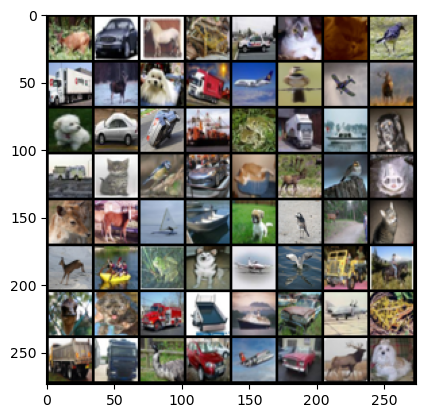

In [38]:
train_iter = iter(data_train_loader)
images, labels = next(train_iter)

plt.imshow(np.transpose(torchvision.utils.make_grid(images), (1, 2, 0)))

### Design neural network

We now have to design the neural network in torch. For that, we should implement a class that is derived from `nn.Module`.

We define the network parts usually in the constructor and call them in the forward method. The easiest solution is to use a `nn.Sequential` object, but there are also other possibilities.

In [39]:
class MyCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # YOUR CODE HERE
        num_classes = 10
        # first filter layer
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1)

        #second filter layer
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1)

        #Pooling layer reduction of the image size
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

         # 4) Fully-connected layers:
        #    After two pools, if the input is 32×32, spatial dimension becomes 8×8 for each of 32 channels
        self.fc1 = nn.Linear(in_features=32 * 8 * 8, out_features=128)
        self.fc2 = nn.Linear(in_features=128, out_features=num_classes)
        
    def forward(self, x):
        # Convolution -> ReLU -> Pool
        x = self.pool(F.relu(self.conv1(x)))  # shape: [batch_size, 16, 16, 16]
        x = self.pool(F.relu(self.conv2(x)))  # shape: [batch_size, 32, 8, 8]
        
        # Flatten for fully-connected layers
        x = x.view(x.size(0), -1)             # shape: [batch_size, 32*8*8]
        
        # Fully-connected -> ReLU -> Fully-connected
        x = F.relu(self.fc1(x))               # shape: [batch_size, 128]
        x = self.fc2(x)                       # shape: [batch_size, num_classes]
        
        return x



In [40]:
my_cnn = MyCNN()
# 
# Print gives some information about the cnn
#
print(my_cnn)
# ... but the output of summary (from torchinfo) gives some extra information
summary(my_cnn, input_size=(64,3, 32,32))

MyCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=2048, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


Layer (type:depth-idx)                   Output Shape              Param #
MyCNN                                    [64, 10]                  --
├─Conv2d: 1-1                            [64, 16, 32, 32]          448
├─MaxPool2d: 1-2                         [64, 16, 16, 16]          --
├─Conv2d: 1-3                            [64, 32, 16, 16]          4,640
├─MaxPool2d: 1-4                         [64, 32, 8, 8]            --
├─Linear: 1-5                            [64, 128]                 262,272
├─Linear: 1-6                            [64, 10]                  1,290
Total params: 268,650
Trainable params: 268,650
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 122.25
Input size (MB): 0.79
Forward/backward pass size (MB): 12.65
Params size (MB): 1.07
Estimated Total Size (MB): 14.51

In [41]:
def get_device():
    if torch.cuda.is_available():
        device = torch.device('cuda')
        # test if it worked
        x = torch.ones(1, device=device)
        print('Using CUDA device')

    elif torch.backends.mps.is_available():
        device = torch.device('mps')
        x = torch.ones(1, device=device)
        print('Using MPS device')
    else:
        print('Using CPU')
        device = torch.device('cpu')
    return device

In [42]:
device = get_device()

Using CUDA device


### Training Loop

In torch, we have to define our own training loop.

In [43]:
def train(epochs: int, model, train_data, val_data, loss_function, optimizer, metrics, device):                                              
    input_count = 0
    step_count = 0
    model = model.to(device)
    
    for epoch in range(epochs):
        model.train()
        metrics.reset()
        for step, (inputs, labels) in enumerate(train_data):
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            # Zero your gradients for every batch!
            optimizer.zero_grad()
            # calculate results
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)

            train_loss = loss_function(outputs, labels)
            train_loss.backward()
            optimizer.step()

            metrics.update(predicted, labels)
            train_acc = metrics.compute()
           
        model.eval()
        metrics.reset()
        val_loss = []
        val_steps = 0
        for step, (inputs, labels) in enumerate(val_data):
            inputs = inputs.to(device)
            labels = labels.to(device)
            with torch.no_grad():
                outputs = model(inputs)
                _, predicted = torch.max(outputs, 1)

                val_loss.append(loss_function(outputs, labels).item())
                metrics.update(predicted, labels)

        val_acc = metrics.compute()
        val_loss_mean = np.mean(val_loss)

        print(f"Epoch {epoch:02} Train Loss: {train_loss:.3f}, Valid Loss: {val_loss_mean:.3f}, Train Accuracy: {train_acc:.2f} Valid Acc: {val_acc:.2f}")
    # return the last accuracy from the evaluation
    return val_acc
                       

In [44]:
my_cnn = MyCNN()
my_metrics = MulticlassAccuracy(num_classes=10)

optimizer = optim.Adam(my_cnn.parameters(), lr=0.001)
loss_function = nn.CrossEntropyLoss()

# initialize an optimizer and loss function and call train
val_acc = train(10, my_cnn, data_train_loader, data_test_loader, loss_function, optimizer, my_metrics, device)
print(val_acc)

Epoch 00 Train Loss: 1.360, Valid Loss: 1.319, Train Accuracy: 0.44 Valid Acc: 0.53
Epoch 01 Train Loss: 0.652, Valid Loss: 1.179, Train Accuracy: 0.56 Valid Acc: 0.58
Epoch 02 Train Loss: 1.233, Valid Loss: 1.057, Train Accuracy: 0.62 Valid Acc: 0.62
Epoch 03 Train Loss: 0.926, Valid Loss: 1.004, Train Accuracy: 0.65 Valid Acc: 0.65
Epoch 04 Train Loss: 0.782, Valid Loss: 0.950, Train Accuracy: 0.68 Valid Acc: 0.67
Epoch 05 Train Loss: 1.046, Valid Loss: 0.920, Train Accuracy: 0.71 Valid Acc: 0.68
Epoch 06 Train Loss: 1.305, Valid Loss: 0.918, Train Accuracy: 0.73 Valid Acc: 0.69
Epoch 07 Train Loss: 0.477, Valid Loss: 0.929, Train Accuracy: 0.74 Valid Acc: 0.68
Epoch 08 Train Loss: 0.428, Valid Loss: 0.957, Train Accuracy: 0.76 Valid Acc: 0.67
Epoch 09 Train Loss: 0.377, Valid Loss: 0.916, Train Accuracy: 0.77 Valid Acc: 0.69
tensor(0.6897)


In [45]:
# you should be able to get about 60% easily :-)
assert my_metrics.compute() > 0.6